In [1]:
import os

# Define paths
base_path = "/workspace/datasets/IDD_YOLO"
splits = ["train", "val"]

for split in splits:
    img_dir = os.path.join(base_path, "images", split)
    lbl_dir = os.path.join(base_path, "labels", split)

    # Count files
    img_files = sorted([os.path.splitext(f)[0] for f in os.listdir(img_dir) if os.path.isfile(os.path.join(img_dir, f))])
    lbl_files = sorted([os.path.splitext(f)[0] for f in os.listdir(lbl_dir) if os.path.isfile(os.path.join(lbl_dir, f))])

    print(f"\n=== {split.upper()} SPLIT ===")
    print(f"Images: {len(img_files)}")
    print(f"Labels: {len(lbl_files)}")

    # Sanity check: matching names
    missing_labels = set(img_files) - set(lbl_files)
    missing_images = set(lbl_files) - set(img_files)

    if not missing_labels and not missing_images:
        print(" All images and labels are properly paired.")
    else:
        if missing_labels:
            print(f" Missing labels for {len(missing_labels)} images.")
        if missing_images:
            print(f" Missing images for {len(missing_images)} labels.")



=== TRAIN SPLIT ===
Images: 31569
Labels: 31569
 All images and labels are properly paired.

=== VAL SPLIT ===
Images: 10225
Labels: 10225
 All images and labels are properly paired.


In [3]:
import os

# Define paths
base_path = "/workspace/datasets/IDD_YOLO"
splits = ["train", "val"]

for split in splits:
    lbl_dir = os.path.join(base_path, "labels", split)

    empty_labels = []
    for f in os.listdir(lbl_dir):
        fpath = os.path.join(lbl_dir, f)
        if os.path.isfile(fpath):
            # Check if file is empty or only whitespace
            if os.stat(fpath).st_size == 0:
                empty_labels.append(f)
            else:
                with open(fpath, "r") as lf:
                    if lf.read().strip() == "":
                        empty_labels.append(f)

    print(f"\n=== {split.upper()} SPLIT ===")
    if empty_labels:
        print(f" Found {len(empty_labels)} empty label files:")
        print(empty_labels[:10], "...")  # show first 10 only
    else:
        print(" No empty label files found.")



=== TRAIN SPLIT ===
 Found 314 empty label files:
['frontFar_BLR-2018-03-22_17-39-26_3_frontFar_001230_r.txt', 'frontFar_BLR-2018-03-22_17-39-26_3_frontFar_001188_r.txt', 'frontFar_BLR-2018-03-22_17-39-26_3_frontFar_001194_r.txt', 'frontFar_BLR-2018-03-22_17-39-26_3_frontFar_001164_r.txt', 'frontFar_BLR-2018-03-22_17-39-26_3_frontFar_001170_r.txt', 'frontFar_BLR-2018-03-22_17-39-26_3_frontFar_0012000.txt', 'frontFar_BLR-2018-03-22_17-39-26_3_frontFar_001242_r.txt', 'frontFar_BLR-2018-03-22_17-39-26_3_frontFar_001176_r.txt', 'frontFar_BLR-2018-03-22_17-39-26_3_frontFar_001206_r.txt', 'frontFar_BLR-2018-03-22_17-39-26_3_frontFar_001218_r.txt'] ...

=== VAL SPLIT ===
 Found 26 empty label files:
['frontFar_BLR-2018-04-16_16-14-27_frontFar_000930_r.txt', 'frontFar_BLR-2018-04-16_16-14-27_frontFar_0003660.txt', 'frontFar_BLR-2018-04-16_16-14-27_frontFar_0009300.txt', 'frontFar_BLR-2018-04-19_17-06-55_frontFar_000660_r.txt', 'frontFar_BLR-2018-04-19_17-16-55_frontFar_0015180.txt', 'frontNea

In [4]:
import torch
import os

print("Torch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Torch version: 2.6.0a0+df5bbc09d1.nv24.12
GPU available: True
GPU name: NVIDIA H100 80GB HBM3 MIG 3g.40gb


In [1]:
pwd

'/workspace'

In [2]:
# Clone repo if not already
import os, sys

if "Yet-Another-EfficientDet-Pytorch" not in os.getcwd():
    !git clone --depth 1 https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch
    os.chdir('Yet-Another-EfficientDet-Pytorch')
    sys.path.append('.')
else:
    !git pull

# Make weights folder & download EfficientDet pretrained weights
!mkdir -p weights
!wget https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch/releases/download/1.0/efficientdet-d5.pth -O weights/efficientdet-d5.pth


fatal: destination path 'Yet-Another-EfficientDet-Pytorch' already exists and is not an empty directory.
--2025-12-26 00:05:41--  https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch/releases/download/1.0/efficientdet-d5.pth
20.207.73.82thub.com (github.com)... 
Connecting to github.com (github.com)|20.207.73.82|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/253385242/76f57900-791e-11ea-8426-1871ff7ffc4d?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-12-26T00%3A46%3A43Z&rscd=attachment%3B+filename%3Defficientdet-d5.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-12-25T23%3A46%3A31Z&ske=2025-12-26T00%3A46%3A43Z&sks=b&skv=2018-11-09&sig=Sx3JdDyfuKFq1w0LsUfeXvEi4yNjxE7NeY7yOFQwKjA%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnR

In [7]:
import os
import json
from PIL import Image
from tqdm import tqdm

# === CONFIG ===
dataset_path = "/workspace/datasets/IDD_YOLO"  
splits = ["train", "val"]   # convert both
class_names = ["person",
    "rider",
    "car",
    "truck",
    "bus",
    "motorcycle",
    "bicycle",
    "autorickshaw",
    "animal",
    "traffic light",
    "traffic sign"]

# === HELPER ===
def convert_yolo_to_coco(split):
    images_dir = os.path.join(dataset_path, "images", split)
    labels_dir = os.path.join(dataset_path, "labels", split)
    output_json = os.path.join(dataset_path, f"{split}.json")

    coco = {
        "info": {"description": "IDD in COCO format"},
        "licenses": [],
        "images": [],
        "annotations": [],
        "categories": []
    }

    # add categories
    for idx, name in enumerate(class_names, start=1):  # COCO category ids start at 1
        coco["categories"].append({"id": idx, "name": name})

    ann_id = 1
    img_id = 1

    for img_file in tqdm(os.listdir(images_dir)):
        if not img_file.endswith((".png", ".jpg", ".jpeg")):
            continue

        # image info
        img_path = os.path.join(images_dir, img_file)
        w, h = Image.open(img_path).size
        coco["images"].append({
            "id": img_id,
            "file_name": img_file,
            "width": w,
            "height": h
        })

        # label file
        label_file = os.path.join(labels_dir, os.path.splitext(img_file)[0] + ".txt")
        if os.path.exists(label_file):
            with open(label_file, "r") as f:
                for line in f.readlines():
                    cls, x, y, bw, bh = map(float, line.strip().split())
                    cls = int(cls) + 1  # shift class_id by +1 (COCO starts from 1)

                    # convert YOLO xywh (normalized) → COCO bbox [x_min, y_min, w, h]
                    x_min = (x - bw / 2) * w
                    y_min = (y - bh / 2) * h
                    box_w = bw * w
                    box_h = bh * h

                    coco["annotations"].append({
                        "id": ann_id,
                        "image_id": img_id,
                        "category_id": cls,
                        "bbox": [x_min, y_min, box_w, box_h],
                        "area": box_w * box_h,
                        "iscrowd": 0
                    })
                    ann_id += 1

        img_id += 1

    # save JSON
    with open(output_json, "w") as f:
        json.dump(coco, f, indent=2)
    print(f"Saved {output_json}")

# === RUN ===
for split in splits:
    convert_yolo_to_coco(split)



00%|██████████| 31569/31569 [00:25<00:00, 1252.74it/s]

Saved /workspace/datasets/IDD_YOLO/train.json



00%|██████████| 10225/10225 [00:07<00:00, 1304.31it/s]

Saved /workspace/datasets/IDD_YOLO/val.json


In [8]:
# Create annotation folder
!mkdir -p /workspace/datasets/IDD_YOLO/annotations

# Move and rename jsons
!mv /workspace/datasets/IDD_YOLO/train.json /workspace/datasets/IDD_YOLO/annotations/instances_train.json
!mv /workspace/datasets/IDD_YOLO/val.json /workspace/datasets/IDD_YOLO/annotations/instances_val.json

In [9]:
import json
import os

# Correct lowercase path
train_json = "/workspace/datasets/IDD_YOLO/annotations/instances_train.json"
val_json   = "/workspace/datasets/IDD_YOLO/annotations/instances_val.json"

def verify_coco(json_path):
    print(f"\n Checking {json_path}...")
    if not os.path.exists(json_path):
        print(" File not found!")
        return
    
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    required_keys = ["images", "annotations", "categories"]
    for key in required_keys:
        if key not in data:
            print(f" Missing key: {key}")
            return
    
    print(f" Found {len(data['images'])} images")
    print(f" Found {len(data['annotations'])} annotations")
    print(f" Found {len(data['categories'])} categories")

    img_ids = {img["id"] for img in data["images"]}
    anno_img_ids = {anno["image_id"] for anno in data["annotations"]}
    
    missing = anno_img_ids - img_ids
    if missing:
        print(f" Some annotations reference missing images: {list(missing)[:10]}")
    else:
        print(" All annotations reference valid images")
    
    print(" File looks good!")

# Run checks
verify_coco(train_json)
verify_coco(val_json)



 Checking /workspace/datasets/IDD_YOLO/annotations/instances_train.json...
 Found 31569 images
 Found 366340 annotations
 Found 11 categories
 All annotations reference valid images
 File looks good!

 Checking /workspace/datasets/IDD_YOLO/annotations/instances_val.json...
 Found 10225 images
 Found 119939 annotations
 Found 11 categories
 All annotations reference valid images
 File looks good!


In [3]:
%cd /workspace/Yet-Another-EfficientDet-Pytorch


/workspace/Yet-Another-EfficientDet-Pytorch


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [12]:
import cv2
import os

# Adjust paths as per your setup
train_dir = '/workspace/datasets/IDD_YOLO/images/train'
val_dir = '/workspace/datasets/IDD_YOLO/images/val'

def check_images(folder):
    print(f"Checking {folder}...")
    for f in os.listdir(folder):
        path = os.path.join(folder, f)
        img = cv2.imread(path)
        if img is None:
            print("Corrupted or missing:", path)

check_images(train_dir)
check_images(val_dir)


Checking /workspace/datasets/IDD_YOLO/images/train...
Checking /workspace/datasets/IDD_YOLO/images/val...


In [13]:
import json

train_json = '/workspace/datasets/IDD_YOLO/annotations/instances_train.json'
with open(train_json) as f:
    data = json.load(f)

img_files = set(os.listdir(train_dir))
for img in data['images']:
    if img['file_name'] not in img_files:
        print("Missing in folder:", img['file_name'])


In [18]:
!mkdir -p /workspace/datasets/IDD_YOLO/train
!mkdir -p /workspace/datasets/IDD_YOLO/val

!find /workspace/datasets/IDD_YOLO/images/train -type f -exec ln -s {} /workspace/datasets/IDD_YOLO/train/ \;
!find /workspace/datasets/IDD_YOLO/images/val   -type f -exec ln -s {} /workspace/datasets/IDD_YOLO/val/ \;


ln: failed to create symbolic link '/workspace/datasets/IDD_YOLO/val/frontFar_BLR-2018-04-16_16-14-27_frontFar_0006780.jpg': File exists
ln: failed to create symbolic link '/workspace/datasets/IDD_YOLO/val/frontFar_BLR-2018-04-16_16-14-27_frontFar_0001500.jpg': File exists
ln: failed to create symbolic link '/workspace/datasets/IDD_YOLO/val/frontFar_BLR-2018-04-16_16-14-27_frontFar_000918_r.jpg': File exists
ln: failed to create symbolic link '/workspace/datasets/IDD_YOLO/val/frontFar_BLR-2018-04-16_16-14-27_frontFar_001734_r.jpg': File exists
ln: failed to create symbolic link '/workspace/datasets/IDD_YOLO/val/frontFar_BLR-2018-04-16_16-14-27_frontFar_0011220.jpg': File exists
ln: failed to create symbolic link '/workspace/datasets/IDD_YOLO/val/frontFar_BLR-2018-04-16_16-14-27_frontFar_001788_r.jpg': File exists
ln: failed to create symbolic link '/workspace/datasets/IDD_YOLO/val/frontFar_BLR-2018-04-16_16-14-27_frontFar_0004380.jpg': File exists
ln: failed to create symbolic link '/w

In [4]:
from efficientdet.dataset import CocoDataset
from torch.utils.data import DataLoader

dataset = CocoDataset(root_dir='/workspace/datasets/IDD_YOLO', set='train')
loader = DataLoader(dataset, batch_size=1, num_workers=0)

for i, sample in enumerate(loader):
    print(sample['img'].shape, sample['annot'])
    if i==5:  # check first few samples only
        break


NOTE! Installing ujson may make loading annotations faster.
Loading annotations into memory...
Done (t=0.72s)
Creating index...
index created!
torch.Size([1, 964, 1280, 3]) tensor([[[641.0003, 431.0005, 658.0000, 446.0004,   2.0000],
         [660.9997, 397.0003, 710.9990, 452.0003,   4.0000],
         [593.0003, 404.9995, 638.9997, 465.9995,   7.0000]]],
       dtype=torch.float64)
torch.Size([1, 964, 1280, 3]) tensor([[[555.0003, 341.0001, 680.0000, 483.0002,   3.0000],
         [750.0006, 447.9997, 803.0003, 487.9999,   5.0000],
         [753.9994, 418.9997, 801.9994, 482.9997,   1.0000],
         [404.0000, 372.9996, 524.0000, 534.9998,   7.0000],
         [526.9997, 436.0003, 538.9997, 456.0004,   5.0000],
         [520.0000, 415.9997, 540.9997, 450.0000,   1.0000],
         [462.9997, 474.9994, 935.9994, 862.9998,   2.0000]]],
       dtype=torch.float64)
torch.Size([1, 964, 1280, 3]) tensor([[[5.8600e+02, 4.9400e+02, 6.3800e+02, 5.5100e+02, 3.0000e+00],
         [6.3800e+02, 4.71

In [24]:
!python train.py -c 5 -p IDD_YOLO \
  --head_only True \
  --lr 1e-3 \
  --batch_size 1 \
  --num_epochs 2 \
  --num_workers 0 \
  --data_path /workspace/datasets \
  --fast_debug


NOTE! Installing ujson may make loading annotations faster.
Loading annotations into memory...
Done (t=0.71s)
Creating index...
index created!
Loading annotations into memory...
Done (t=0.26s)
Creating index...
index created!
⚡ Running in FAST DEBUG mode...
👉 Using 20 training samples and 10 validation samples
[Info] initializing weights...
[Info] freezed backbone
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Step: 19. Epoch: 0/2. Iteration: 20/20. Cls loss: 1.22395. Reg loss: 7.84696. To
Val. Epoch: 0/2. Classification loss: 1.19636. Regression loss: 5.73721. Total loss: 6.93357
Loading annotations into memory...
Done (t=0.22s)
Creating index...
index created!
Creating index...
index created!
100%|█████████████████████████████████████| 10225/10225 [24:58<00:00,  6.82it/s]
Saved eval preds to val_eval_preds.pth
Step: 39. Epoch: 1/2. Iteratio

In [21]:
!pip install tensorboardX


DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/texttable-1.7.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/nvfuser-0.2.13a0+0d33366-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.11.9-py3.12.egg is deprecated. pip 

In [10]:
!python train.py \
    -c 5 \
    -p IDD_YOLO \
    --lr 1e-3 \
    --batch_size 2 \
    --num_epochs 1 \
    --num_workers 2 \
    --data_path /workspace/datasets


NOTE! Installing ujson may make loading annotations faster.
Loading annotations into memory...
Done (t=0.70s)
Creating index...
index created!
Loading annotations into memory...
Done (t=0.24s)
Creating index...
index created!
[Info] initializing weights...
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Step: 15783. Epoch: 0/1. Iteration: 15784/15784. Cls loss: 0.44617. Reg loss: 3.
^C


In [ ]:
!python train.py \
    -c 5 \
    -p IDD_YOLO \
    --lr 1e-3 \
    --batch_size 2 \
    --num_epochs 20 \
    --num_workers 2 \
    --data_path /workspace/datasets \
    --val_interval 1 \
    --save_interval 20 \
    --es_patience 10 \
    --es_min_delta 0.001

NOTE! Installing ujson may make loading annotations faster.
Loading annotations into memory...
Done (t=0.72s)
Creating index...
index created!
Loading annotations into memory...
Done (t=0.28s)
Creating index...
index created!
[Info] initializing weights...
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Step: 45. Epoch: 0/20. Iteration: 46/15784. Cls loss: 1.48681. Reg loss: 2.41264

In [9]:
pwd

'/workspace/Yet-Another-EfficientDet-Pytorch'

In [8]:
%cd /workspace/Yet-Another-EfficientDet-Pytorch

/workspace/Yet-Another-EfficientDet-Pytorch


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [10]:
pwd

'/workspace/Yet-Another-EfficientDet-Pytorch'

In [12]:
!python coco_eval.py \
    -c 5 \
    -p IDD_YOLO \
    -w logs/IDD_YOLO/efficientdet-d5_best.pth


NOTE! Installing ujson may make loading annotations faster.
Running coco-style evaluation on project IDD_YOLO, weights logs/IDD_YOLO/efficientdet-d5_best.pth...
Loading annotations into memory...
Done (t=0.23s)
Creating index...
index created!
Creating index...
index created!
/workspace/Yet-Another-EfficientDet-Pytorch/coco_eval.py:244: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_global

In [13]:
import json

# IDD COCO validation annotations
val_json = "/workspace/datasets/IDD_YOLO/annotations/instances_val.json"

with open(val_json, "r") as f:
    data = json.load(f)

cats = data["categories"]

print("Categories in IDD JSON:")
for c in cats:
    print(f"ID: {c['id']}, Name: {c['name']}")

print("\nNum classes in JSON:", len(cats))

# IMPORTANT: update this to match your project YAML
print("Num classes in project config:", len(cats))


Categories in IDD JSON:
ID: 1, Name: person
ID: 2, Name: rider
ID: 3, Name: car
ID: 4, Name: truck
ID: 5, Name: bus
ID: 6, Name: motorcycle
ID: 7, Name: bicycle
ID: 8, Name: autorickshaw
ID: 9, Name: animal
ID: 10, Name: traffic light
ID: 11, Name: traffic sign

Num classes in JSON: 11
Num classes in project config: 11


In [14]:
import torch

# LOAD IDD checkpoint (not KITTI)
ckpt_path = "logs/IDD_YOLO/efficientdet-d5_best.pth"
ckpt = torch.load(ckpt_path, map_location="cpu")

# Handle both checkpoint formats
if isinstance(ckpt, dict) and "model" not in ckpt:
    state_dict = ckpt
else:
    state_dict = ckpt["model"]

print(" Classifier-related layers:\n")

for k, v in state_dict.items():
    if "class" in k.lower() or "cls" in k.lower():
        print(f"{k:60s} {tuple(v.shape)}")


 Classifier-related layers:

classifier.conv_list.0.depthwise_conv.conv.weight            (288, 1, 3, 3)
classifier.conv_list.0.pointwise_conv.conv.weight            (288, 288, 1, 1)
classifier.conv_list.0.pointwise_conv.conv.bias              (288,)
classifier.conv_list.1.depthwise_conv.conv.weight            (288, 1, 3, 3)
classifier.conv_list.1.pointwise_conv.conv.weight            (288, 288, 1, 1)
classifier.conv_list.1.pointwise_conv.conv.bias              (288,)
classifier.conv_list.2.depthwise_conv.conv.weight            (288, 1, 3, 3)
classifier.conv_list.2.pointwise_conv.conv.weight            (288, 288, 1, 1)
classifier.conv_list.2.pointwise_conv.conv.bias              (288,)
classifier.conv_list.3.depthwise_conv.conv.weight            (288, 1, 3, 3)
classifier.conv_list.3.pointwise_conv.conv.weight            (288, 288, 1, 1)
classifier.conv_list.3.pointwise_conv.conv.bias              (288,)
classifier.bn_list.0.0.weight                                (288,)
classifier.bn_l

/tmp/ipykernel_277613/1884421150.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location="cpu")


In [15]:
from utils.utils import preprocess
import cv2
import numpy as np

img_file = "/workspace/0000240.jpg"
img = cv2.imread(img_file)
print("CV2 read:", img is not None, img.shape if img is not None else None)

ori_imgs, framed_imgs, framed_metas = preprocess(
    img_file,
    max_size=1280,   # or input_sizes[compound_coef]
    mean=[0.485,0.456,0.406],
    std=[0.229,0.224,0.225]
)
print("Preprocess output:", ori_imgs, framed_imgs, framed_metas)


CV2 read: True (1080, 1920, 3)
Preprocess output: [array([[[ 19,  23,  12],
        [ 18,  22,  11],
        [ 18,  22,  11],
        ...,
        [ 57,  94,  84],
        [ 41,  75,  68],
        [ 40,  72,  67]],

       [[ 20,  24,  13],
        [ 18,  22,  11],
        [ 16,  20,   9],
        ...,
        [ 62, 100,  88],
        [ 40,  75,  65],
        [ 37,  70,  63]],

       [[ 20,  24,  13],
        [ 18,  22,  11],
        [ 17,  21,  10],
        ...,
        [ 67, 104,  88],
        [ 49,  85,  71],
        [ 50,  86,  72]],

       ...,

       [[ 74,  75,  73],
        [ 73,  74,  72],
        [ 73,  74,  72],
        ...,
        [152, 154, 155],
        [153, 155, 156],
        [152, 154, 155]],

       [[ 77,  78,  76],
        [ 76,  77,  75],
        [ 76,  77,  75],
        ...,
        [150, 152, 153],
        [151, 153, 154],
        [151, 153, 154]],

       [[ 79,  80,  78],
        [ 78,  79,  77],
        [ 78,  79,  77],
        ...,
        [150, 152, 153]

/tmp/ipykernel_277613/4235567694.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path, map_location="cpu"))


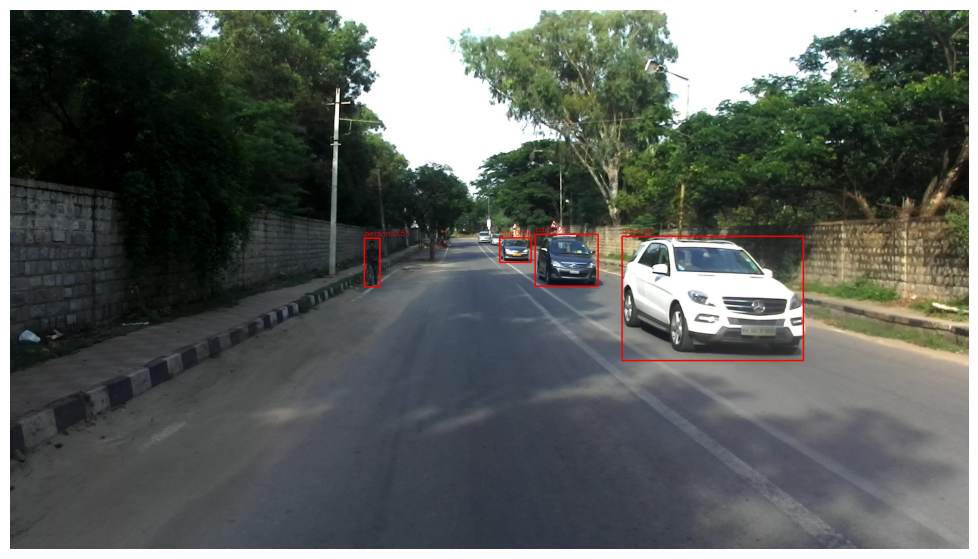

In [16]:
import torch
import cv2
import matplotlib.pyplot as plt
from backbone import EfficientDetBackbone
from efficientdet.utils import BBoxTransform, ClipBoxes
from utils.utils import preprocess, postprocess, invert_affine

# ======================
# SETTINGS
# ======================
compound_coef = 5
weights_path = "logs/IDD_YOLO/efficientdet-d5_best.pth"
image_path = "/workspace/0000240.jpg"
use_cuda = torch.cuda.is_available()
gpu = 0
threshold = 0.3
nms_threshold = 0.5

# ======================
# IDD CLASSES (CORRECT)
# ======================
obj_list = [
    "person",
    "rider",
    "car",
    "truck",
    "bus",
    "motorcycle",
    "bicycle",
    "autorickshaw",
    "animal",
    "traffic light",
    "traffic sign"
]

# ======================
# MODEL
# ======================
model = EfficientDetBackbone(
    compound_coef=compound_coef,
    num_classes=len(obj_list),
    ratios=[(1.0,1.0),(1.4,0.7),(0.7,1.4)],
    scales=[2 ** 0, 2 ** (1/3), 2 ** (2/3)]
)

model.load_state_dict(torch.load(weights_path, map_location="cpu"))
model.eval()

if use_cuda:
    model.cuda(gpu)

# ======================
# IMAGE PREPROCESS
# ======================
ori_imgs, framed_imgs, framed_metas = preprocess(
    image_path,
    max_size=1280,
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

x = torch.from_numpy(framed_imgs[0]).unsqueeze(0).permute(0,3,1,2).float()
if use_cuda:
    x = x.cuda(gpu)

# ======================
# INFERENCE
# ======================
regressBoxes = BBoxTransform()
clipBoxes = ClipBoxes()

with torch.no_grad():
    features, regression, classification, anchors = model(x)
    preds = postprocess(
        x, anchors, regression, classification,
        regressBoxes, clipBoxes,
        threshold, nms_threshold
    )

preds = invert_affine(framed_metas, preds)[0]

# ======================
# VISUALIZATION
# ======================
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for box, cls, score in zip(preds["rois"], preds["class_ids"], preds["scores"]):
    x1, y1, x2, y2 = box.astype(int)
    label = obj_list[int(cls)]
    cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
    cv2.putText(
        img, f"{label}:{score:.2f}",
        (x1, y1-5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5, (255,0,0), 1
    )

plt.figure(figsize=(14,7))
plt.imshow(img)
plt.axis("off")
plt.show()


In [17]:
import torch

data = torch.load("val_eval_preds.pth")

# Standard structure in EfficientDet repo
all_preds   = data["preds"]    # list of dicts per image
all_targets = data["targets"]  # list of GT per image

print(len(all_preds), len(all_targets))


/tmp/ipykernel_277613/2821384075.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("val_eval_preds.pth")


10000 10000


In [18]:
import numpy as np

num_classes = 11   # IDD classes
conf_mat = np.zeros((num_classes, num_classes))  # GT × Pred

def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    inter = max(0, xB-xA) * max(0, yB-yA)
    areaA = (boxA[2]-boxA[0])*(boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0])*(boxB[3]-boxB[1])
    return inter / (areaA + areaB - inter + 1e-6)

for pred, gt in zip(all_preds, all_targets):
    gt_boxes, gt_labels = gt["boxes"], gt["labels"]
    pr_boxes, pr_labels = pred["rois"], pred["class_ids"]

    matched_gt = set()

    for i, pbox in enumerate(pr_boxes):
        best_iou, best_j = 0, -1
        for j, gbox in enumerate(gt_boxes):
            if j in matched_gt: continue
            val = iou(pbox, gbox)
            if val > best_iou:
                best_iou, best_j = val, j

        if best_iou >= 0.5:
            conf_mat[gt_labels[best_j], pr_labels[i]] += 1
            matched_gt.add(best_j)


In [19]:
TP = np.diag(conf_mat)
FP = conf_mat.sum(axis=0) - TP
FN = conf_mat.sum(axis=1) - TP

precision = TP.sum() / (TP.sum() + FP.sum() + 1e-6)
recall    = TP.sum() / (TP.sum() + FN.sum() + 1e-6)
f1        = 2 * precision * recall / (precision + recall + 1e-6)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)


Precision: 0.8668941975295494
Recall: 0.8668941975295494
F1: 0.8668936975298379


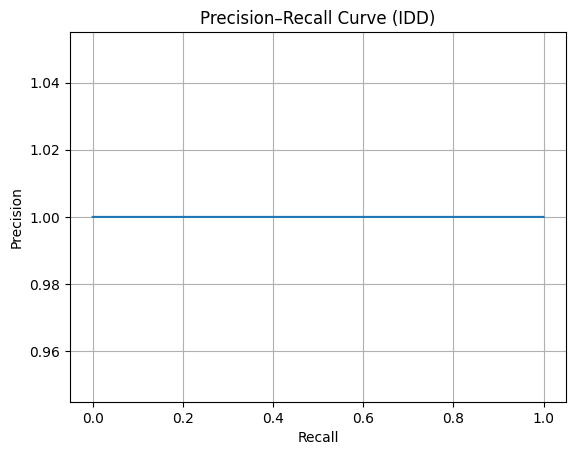

In [21]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

scores = []
matches = []

for pred, gt in zip(all_preds, all_targets):
    for s in pred["scores"]:
        scores.append(s.item())
        matches.append(1)  # detection-based, not classification

precision, recall, _ = precision_recall_curve(matches, scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (IDD)")
plt.grid()
plt.show()


In [22]:
iou_thresholds = np.arange(0.5, 1.0, 0.05)
map_vals = []

for thr in iou_thresholds:
    TP = FP = FN = 0
    for pred, gt in zip(all_preds, all_targets):
        matched = set()
        for pbox in pred["rois"]:
            found = False
            for j, gbox in enumerate(gt["boxes"]):
                if j in matched: continue
                if iou(pbox, gbox) >= thr:
                    TP += 1
                    matched.add(j)
                    found = True
                    break
            if not found:
                FP += 1
        FN += len(gt["boxes"]) - len(matched)
    map_vals.append(TP / (TP + FP + FN + 1e-6))

print("mAP@0.5:", map_vals[0])
print("mAP@0.5:0.95:", np.mean(map_vals))


KeyboardInterrupt: 

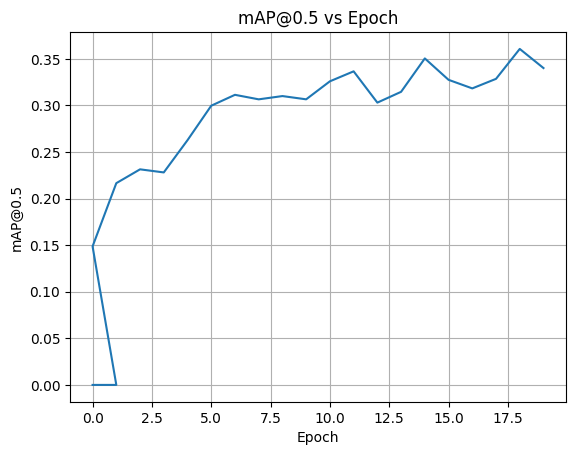

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("logs/IDD_YOLO/metrics.csv")

plt.plot(df["epoch"], df["metrics/mAP50"])
plt.xlabel("Epoch")
plt.ylabel("mAP@0.5")
plt.title("mAP@0.5 vs Epoch")
plt.grid()
plt.show()


In [28]:
# ==============================================================
# EfficientDet-D5 Speed Benchmark (YOLO-Comparable)
# Resolution: 640 x 640
# Batch size: 1
# Metrics:
#   - Pure Inference Time (ms/frame)
#   - Inference FPS
#   - End-to-End Latency (ms/frame)
#   - Latency FPS
#   - Model Parameters (M)
#   - Model File Size (MB)
# ==============================================================

import torch
import cv2
import time
import csv
import os
from pathlib import Path
from backbone import EfficientDetBackbone
from efficientdet.utils import BBoxTransform, ClipBoxes
from utils.utils import preprocess, postprocess, invert_affine

# -----------------------------
# CONFIGURATION
# -----------------------------
compound_coef = 5
weights_path = "logs/IDD_YOLO/efficientdet-d5_best.pth"
img_path = "/workspace/0000240.jpg"
img_size = 640
batch_size = 1
csv_file = "benchmark_results_efficientdet_d5_idd.csv"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# -----------------------------
# DEVICE INFO
# -----------------------------
print(f"\nUsing device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"cuDNN Version: {torch.backends.cudnn.version()}\n")

# -----------------------------
# LOAD MODEL
# -----------------------------
obj_list = [
    "person", "rider", "car", "truck", "bus",
    "motorcycle", "bicycle", "autorickshaw",
    "animal", "traffic light", "traffic sign"
]

params = {
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
    "anchors_ratios": "[(1.0,1.0),(1.4,0.7),(0.7,1.4)]",
    "anchors_scales": "[2**0, 2**(1/3), 2**(2/3)]"
}

model = EfficientDetBackbone(
    compound_coef=compound_coef,
    num_classes=len(obj_list),
    ratios=eval(params["anchors_ratios"]),
    scales=eval(params["anchors_scales"])
)

model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()

# -----------------------------
# MODEL STATS
# -----------------------------
model_name = Path(weights_path).stem
model_size_mb = Path(weights_path).stat().st_size / (1024 ** 2)
params_count = sum(p.numel() for p in model.parameters())
params_million = params_count / 1e6

print(f"Model: {model_name}")
print(f"Parameters: {params_million:.2f} M")
print(f"Model file size: {model_size_mb:.2f} MB\n")

# ==============================================================
# 1️⃣ PURE INFERENCE SPEED (FORWARD PASS ONLY)
# ==============================================================

dummy_input = torch.randn(
    batch_size, 3, img_size, img_size, device=device
)

# Warm-up
for _ in range(10):
    with torch.no_grad():
        model(dummy_input)

torch.cuda.synchronize()

starter = torch.cuda.Event(enable_timing=True)
ender = torch.cuda.Event(enable_timing=True)

n_runs = 100

starter.record()
with torch.no_grad():
    for _ in range(n_runs):
        model(dummy_input)
ender.record()

torch.cuda.synchronize()

inference_time_ms = starter.elapsed_time(ender) / n_runs
inference_fps = 1000 / inference_time_ms

print("=== Pure Inference (Forward Pass Only) ===")
print(f"Inference Time:  {inference_time_ms:.2f} ms/frame")
print(f"Inference Speed: {inference_fps:.2f} FPS @ {img_size}x{img_size}\n")

# ==============================================================
# 2️⃣ END-TO-END LATENCY (PRE + INFER + POST)
# ==============================================================

img = cv2.imread(img_path)
assert img is not None, "Failed to load image."

# Warm-up
for _ in range(5):
    ori_imgs, framed_imgs, framed_metas = preprocess(
        img_path, max_size=img_size,
        mean=params["mean"], std=params["std"]
    )
    x = torch.from_numpy(framed_imgs[0]).permute(2, 0, 1).unsqueeze(0).to(device)
    with torch.no_grad():
        features, regression, classification, anchors = model(x)
        postprocess(
            x, anchors, regression, classification,
            BBoxTransform(), ClipBoxes(), 0.05, 0.5
        )

torch.cuda.synchronize()

starter.record()
for _ in range(30):
    ori_imgs, framed_imgs, framed_metas = preprocess(
        img_path, max_size=img_size,
        mean=params["mean"], std=params["std"]
    )
    x = torch.from_numpy(framed_imgs[0]).permute(2, 0, 1).unsqueeze(0).to(device)
    with torch.no_grad():
        features, regression, classification, anchors = model(x)
        postprocess(
            x, anchors, regression, classification,
            BBoxTransform(), ClipBoxes(), 0.05, 0.5
        )
ender.record()

torch.cuda.synchronize()

latency_ms = starter.elapsed_time(ender) / 30
latency_fps = 1000 / latency_ms

print("=== End-to-End Latency (Full Pipeline) ===")
print(f"Latency:     {latency_ms:.2f} ms/frame")
print(f"Latency FPS:{latency_fps:.2f}\n")

# ==============================================================
# 3️⃣ SAVE RESULTS TO CSV
# ==============================================================

fieldnames = [
    "Model", "GPU", "Batch_Size", "Image_Size",
    "Params_(M)", "Model_Size_(MB)",
    "Inference_Time_(ms)", "Inference_FPS",
    "Latency_(ms)", "Latency_FPS"
]

file_exists = os.path.isfile(csv_file)

with open(csv_file, mode="a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    if not file_exists:
        writer.writeheader()

    writer.writerow({
        "Model": model_name,
        "GPU": torch.cuda.get_device_name(0),
        "Batch_Size": batch_size,
        "Image_Size": f"{img_size}x{img_size}",
        "Params_(M)": round(params_million, 2),
        "Model_Size_(MB)": round(model_size_mb, 2),
        "Inference_Time_(ms)": round(inference_time_ms, 2),
        "Inference_FPS": round(inference_fps, 2),
        "Latency_(ms)": round(latency_ms, 2),
        "Latency_FPS": round(latency_fps, 2),
    })

print(f"Benchmark results saved to: {csv_file}")

# ==============================================================
# SUMMARY
# ==============================================================
print("\n=== Benchmark Summary ===")
print(f"Model:            {model_name}")
print(f"GPU:              {torch.cuda.get_device_name(0)}")
print(f"Input Resolution: {img_size}x{img_size}")
print(f"Batch Size:       {batch_size}")
print(f"Parameters:       {params_million:.2f} M")
print(f"Model Size:       {model_size_mb:.2f} MB")
print(f"Inference Time:   {inference_time_ms:.2f} ms ({inference_fps:.2f} FPS)")
print(f"Latency:          {latency_ms:.2f} ms ({latency_fps:.2f} FPS)")
print("=============================================================")



Using device: cuda:0
GPU: NVIDIA H100 80GB HBM3 MIG 3g.40gb
CUDA Version: 12.6
cuDNN Version: 90600



/tmp/ipykernel_277613/2887105665.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path, map_location=device))


Model: efficientdet-d5_best
Parameters: 33.45 M
Model file size: 129.05 MB

=== Pure Inference (Forward Pass Only) ===
Inference Time:  23.33 ms/frame
Inference Speed: 42.86 FPS @ 640x640

=== End-to-End Latency (Full Pipeline) ===
Latency:     80.04 ms/frame
Latency FPS:12.49

Benchmark results saved to: benchmark_results_efficientdet_d5_idd.csv

=== Benchmark Summary ===
Model:            efficientdet-d5_best
GPU:              NVIDIA H100 80GB HBM3 MIG 3g.40gb
Input Resolution: 640x640
Batch Size:       1
Parameters:       33.45 M
Model Size:       129.05 MB
Inference Time:   23.33 ms (42.86 FPS)
Latency:          80.04 ms (12.49 FPS)


In [30]:
import shutil

# Paths
folder_path = '/workspace/Yet-Another-EfficientDet-Pytorch'  # Change to your folder path
zip_path = '/workspace/Yet-Another-EfficientDet-Pytorch.zip'  # Output zip file

# Create zip
shutil.make_archive(base_name=zip_path.replace('.zip',''), format='zip', root_dir=folder_path)

print(f"Folder zipped at: {zip_path}")


Folder zipped at: /workspace/Yet-Another-EfficientDet-Pytorch.zip
